<a href="https://colab.research.google.com/github/kosar-am/rice-classification-cnn/blob/main/notebooks/04_pytorch_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rice Image Classification using PyTorch


## Import Required Libraries

# Install Kaggle



In [1]:
# Install Kaggle

!pip install -q kagglehub

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import os
import kagglehub

## Configure Device

In [3]:
# Configure the device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cpu


## Mount Google Drive

In [4]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## Define Project Paths

In [5]:
# Project paths

PROJECT_PATH = "/content/drive/MyDrive/My-Project/Rice-Classification-2026"

PYTORCH_PATH = f"{PROJECT_PATH}/pytorch"

MODEL_PATH = f"{PYTORCH_PATH}/models/rice_cnn_model2026.pth"

RESULTS_PATH = f"{PYTORCH_PATH}/results"

In [6]:
# Create project directories

import os

os.makedirs(f"{PYTORCH_PATH}/models", exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

print("Project directories are ready!")

Project directories are ready!


## Install and Configure Kaggle API

In [7]:
# Create Kaggle directory

os.makedirs("/root/.kaggle", exist_ok=True)

## Download the Dataset from Kaggle

In [8]:
# Download the Rice Image Dataset from Kaggle

dataset_path = kagglehub.dataset_download(
    "muratkokludataset/rice-image-dataset"
)

print("Dataset downloaded to:")
print(dataset_path)

100%|██████████| 219M/219M [00:01<00:00, 144MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1


## Locate the Dataset Directory

In [9]:
# Locate the dataset directory


for root, dirs, files in os.walk(dataset_path):
    print(root)

/root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1
/root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1/Rice_Image_Dataset
/root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1/Rice_Image_Dataset/Basmati
/root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1/Rice_Image_Dataset/Ipsala
/root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1/Rice_Image_Dataset/Jasmine
/root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1/Rice_Image_Dataset/Arborio
/root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1/Rice_Image_Dataset/Karacadag


## Define Dataset Path

In [10]:
# Dataset path

DATASET_PATH = os.path.join(
    dataset_path,
    "Rice_Image_Dataset"
)

print(DATASET_PATH)

/root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1/Rice_Image_Dataset


## Define Image Transformations

In [13]:
# Define image transformations

image_transform = transforms.Compose([
    transforms.Resize((250, 250)),
    transforms.ToTensor()
])

In [14]:
print(image_transform)

Compose(
    Resize(size=(250, 250), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


## Load the Dataset

In [15]:
# Load the dataset

dataset = datasets.ImageFolder(
    root=DATASET_PATH,
    transform=image_transform
)

In [16]:
print("Number of images:", len(dataset))

print("Classes:", dataset.classes)

print("Class to index:", dataset.class_to_idx)

Number of images: 75000
Classes: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
Class to index: {'Arborio': 0, 'Basmati': 1, 'Ipsala': 2, 'Jasmine': 3, 'Karacadag': 4}


## Split the Dataset

In [17]:
# Split the dataset into training and validation sets

TRAIN_RATIO = 0.80

train_size = int(TRAIN_RATIO * len(dataset))
validation_size = len(dataset) - train_size

train_dataset, validation_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, validation_size],
    generator=torch.Generator().manual_seed(42)
)

In [18]:
print("Training images:", len(train_dataset))
print("Validation images:", len(validation_dataset))

Training images: 60000
Validation images: 15000


## Create DataLoaders

In [19]:
# Create DataLoaders

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [20]:
print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))

Training batches: 1875
Validation batches: 469


## Explore the Dataset

In [21]:
# Display dataset information

print("Training samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))

print("\nClasses:")
print(dataset.classes)

Training samples: 60000
Validation samples: 15000

Classes:
['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


In [22]:
# Display one sample image

image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Class:", dataset.classes[label])

Image shape: torch.Size([3, 250, 250])
Label: 2
Class: Ipsala


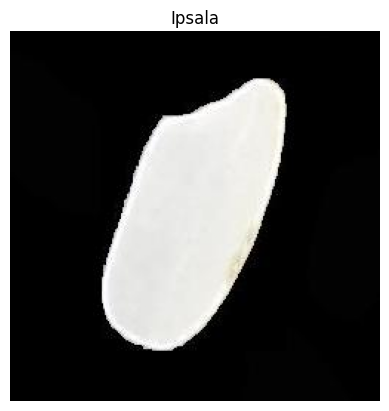

In [23]:
# Show the sample image

plt.imshow(image.permute(1, 2, 0))
plt.title(dataset.classes[label])
plt.axis("off")

plt.show()

## Build the CNN Model

### Build CNN Version 1 (Baseline)

In [24]:
# Build a simple CNN baseline model

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(
            32 * 125 * 125,
            128
        )

        self.fc2 = nn.Linear(
            128,
            5
        )

    def forward(self, x):
        x = self.conv(x)
        x = torch.relu(x)

        x = self.pool(x)

        x = self.flatten(x)

        x = self.fc1(x)
        x = torch.relu(x)

        x = self.fc2(x)

        return x

In [25]:
model = SimpleCNN().to(device)

print(model)

SimpleCNN(
  (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=500000, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)


### Build CNN Version 2


In [26]:
class CNNVersion2(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(
            64 * 62 * 62,
            128
        )

        self.fc2 = nn.Linear(
            128,
            5
        )

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool1(x)

        x = torch.relu(self.conv2(x))
        x = self.pool2(x)

        x = self.flatten(x)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [27]:
model_v2 = CNNVersion2().to(device)

print(model_v2)

CNNVersion2(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=246016, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)


### Build CNN Version 3

In [28]:
class CNNVersion3(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=1
        )

        self.pool3 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(
            128 * 31 * 31,
            128
        )

        self.fc2 = nn.Linear(
            128,
            5
        )

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool1(x)

        x = torch.relu(self.conv2(x))
        x = self.pool2(x)

        x = torch.relu(self.conv3(x))
        x = self.pool3(x)

        x = self.flatten(x)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [29]:
model_v3 = CNNVersion3().to(device)

print(model_v3)

CNNVersion3(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=123008, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)


## Build an Optimized CNN

In [30]:
class EfficientCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=1
        )

        self.pool3 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.global_pool = nn.AdaptiveAvgPool2d(
            output_size=(1, 1)
        )

        self.fc1 = nn.Linear(
            128,
            128
        )

        self.fc2 = nn.Linear(
            128,
            5
        )

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool1(x)

        x = torch.relu(self.conv2(x))
        x = self.pool2(x)

        x = torch.relu(self.conv3(x))
        x = self.pool3(x)

        x = self.global_pool(x)

        x = torch.flatten(x, start_dim=1)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [31]:
efficient_cnn = EfficientCNN().to(device)

print(efficient_cnn)

EfficientCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)
